<a href="https://colab.research.google.com/github/mabdulatalhakh213-ux/Northstar/blob/main/Northstar_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
install.packages(c(
  "dplyr","ggplot2","readr","lubridate","forcats","scales","patchwork"
), repos = "https://cloud.r-project.org")

library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)
library(forcats)
library(scales)
library(patchwork)

base <- "https://raw.githubusercontent.com/mabdulatalhakh213-ux/Northstar/main/"

customers  <- read_csv(paste0(base, "customers.csv"), show_col_types = FALSE)
orders     <- read_csv(paste0(base, "orders.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(base, "deliveries.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(base, "complaints.csv"), show_col_types = FALSE)
app_events <- read_csv(paste0(base, "app_events.csv"), show_col_types = FALSE)
drivers    <- read_csv(paste0(base, "drivers.csv"), show_col_types = FALSE)
incidents  <- read_csv(paste0(base, "incidents.csv"), show_col_types = FALSE)
hubs       <- read_csv(paste0(base, "hubs.csv"), show_col_types = FALSE)
vehicles   <- read_csv(paste0(base, "vehicles.csv"), show_col_types = FALSE)

cat("All CSV files loaded successfully\n")
print(dim(deliveries))
print(head(deliveries, 3))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



All CSV files loaded successfully
[1] 950  13
# A tibble: 3 × 13
  delivery_id order_id driver_id vehicle_id hub_id dispatch_time      
  <chr>       <chr>    <chr>     <chr>      <chr>  <dttm>             
1 DL00001     O00938   D004      V056       H05    2024-06-18 10:57:00
2 DL00002     O00004   D138      V007       H02    2025-01-11 18:45:00
3 DL00003     O00639   D006      V049       H02    2025-06-02 20:39:00
# ℹ 7 more variables: delivery_completed_at <dttm>, delivery_status <chr>,
#   route_distance_km <dbl>, manual_route_override_count <dbl>,
#   proof_of_completion_missing <dbl>, customer_rating_post_delivery <dbl>,
#   fuel_or_charge_cost <dbl>


In [21]:
orders <- orders %>%
  mutate(
    order_created_at = ymd_hms(order_created_at),
    order_value = as.numeric(order_value),
    promised_window_hours = as.numeric(promised_window_hours)
  )

deliveries <- deliveries %>%
  mutate(
    dispatch_time = ymd_hms(dispatch_time),
    delivery_completed_at = ymd_hms(delivery_completed_at),
    route_distance_km = as.numeric(route_distance_km),
    manual_route_override_count = as.numeric(manual_route_override_count),
    customer_rating_post_delivery = as.numeric(customer_rating_post_delivery),
    fuel_or_charge_cost = as.numeric(fuel_or_charge_cost),
    delivery_duration_hours = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours")),
    delivery_duration_hours = ifelse(delivery_duration_hours < 0, NA, delivery_duration_hours),
    is_failed = ifelse(tolower(delivery_status) == "failed", 1, 0),
    is_delayed = ifelse(tolower(delivery_status) == "delayed", 1, 0),
    is_ontime = ifelse(tolower(delivery_status) == "ontime", 1, 0)
  )

complaints <- complaints %>%
  mutate(
    created_at = ymd_hms(created_at),
    resolution_days = as.numeric(resolution_days),
    compensation_amount = as.numeric(compensation_amount)
  )

app_events <- app_events %>%
  mutate(
    event_timestamp = ymd_hms(event_timestamp),
    api_latency_ms = as.numeric(api_latency_ms),
    success_flag = as.numeric(success_flag)
  )

drivers <- drivers %>%
  mutate(
    years_experience = as.numeric(years_experience),
    training_score = as.numeric(training_score),
    driver_rating = as.numeric(driver_rating)
  )

incidents <- incidents %>%
  mutate(
    reported_at = ymd_hms(reported_at),
    resolved_hours = as.numeric(resolved_hours)
  )

vehicles <- vehicles %>%
  mutate(
    battery_health_pct = as.numeric(battery_health_pct),
    odometer_km = as.numeric(odometer_km)
  )

summary(deliveries$delivery_duration_hours)
table(deliveries$delivery_status, useNA = "ifany")

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `dispatch_time = ymd_hms(dispatch_time)`.
Caused by warning:
!  1 failed to parse.”


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.      NAs 
 0.02257  3.48612  7.91229 10.31020 15.46514 43.45692       84 


Delayed  Failed  OnTime 
    202     132     616 

In [22]:
hub_summary <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    total_deliveries = n(),
    avg_delivery_hours = mean(delivery_duration_hours, na.rm = TRUE),
    failure_rate_pct = mean(is_failed, na.rm = TRUE) * 100,
    delay_rate_pct = mean(is_delayed, na.rm = TRUE) * 100,
    avg_override_count = mean(manual_route_override_count, na.rm = TRUE),
    avg_customer_rating = mean(customer_rating_post_delivery, na.rm = TRUE)
  ) %>%
  left_join(hubs, by = "hub_id") %>%
  arrange(desc(failure_rate_pct), desc(delay_rate_pct))

print(hub_summary)

# A tibble: 8 × 11
  hub_id total_deliveries avg_delivery_hours failure_rate_pct delay_rate_pct
  <chr>             <int>              <dbl>            <dbl>          <dbl>
1 H08                 128              10.6             20.3            17.2
2 H05                 115              11.6             20              21.7
3 H06                 104               9.85            14.4            26.0
4 H04                 127              11.1             12.6            22.0
5 H01                 136              10.7             12.5            19.1
6 H07                 115              10.5             12.2            21.7
7 H02                 106               9.48             9.43           24.5
8 H03                 119               8.44             9.24           19.3
# ℹ 6 more variables: avg_override_count <dbl>, avg_customer_rating <dbl>,
#   hub_name <chr>, zone <chr>, hub_type <chr>, capacity_score <dbl>


In [23]:
complaint_summary <- complaints %>%
  group_by(complaint_type, channel) %>%
  summarise(
    total_cases = n(),
    avg_resolution_days = mean(resolution_days, na.rm = TRUE),
    total_compensation = sum(compensation_amount, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(total_compensation), desc(total_cases))

print(complaint_summary)

# A tibble: 28 × 5
   complaint_type  channel total_cases avg_resolution_days total_compensation
   <chr>           <chr>         <int>               <dbl>              <dbl>
 1 Delay           App              31                7.81               577.
 2 MissedPickup    App              20                7.9                441.
 3 Delay           Chatbot          25                6.4                428.
 4 Delay           Phone            24                6.42               392.
 5 DriverBehaviour Phone            18                8.33               372.
 6 MissedPickup    Phone            19                6.21               358.
 7 MissedPickup    Chatbot          14                9.71               346.
 8 Delay           Email            21                8.43               300.
 9 AppIssue        Phone            14               10.9                299.
10 MissedPickup    Email            11                7                  279.
# ℹ 18 more rows


In [24]:
theme_hi <- function() {
  theme_minimal(base_size = 13) +
    theme(
      plot.title = element_text(face = "bold", size = 16),
      plot.subtitle = element_text(color = "gray40"),
      panel.grid.minor = element_blank(),
      legend.position = "top"
    )
}

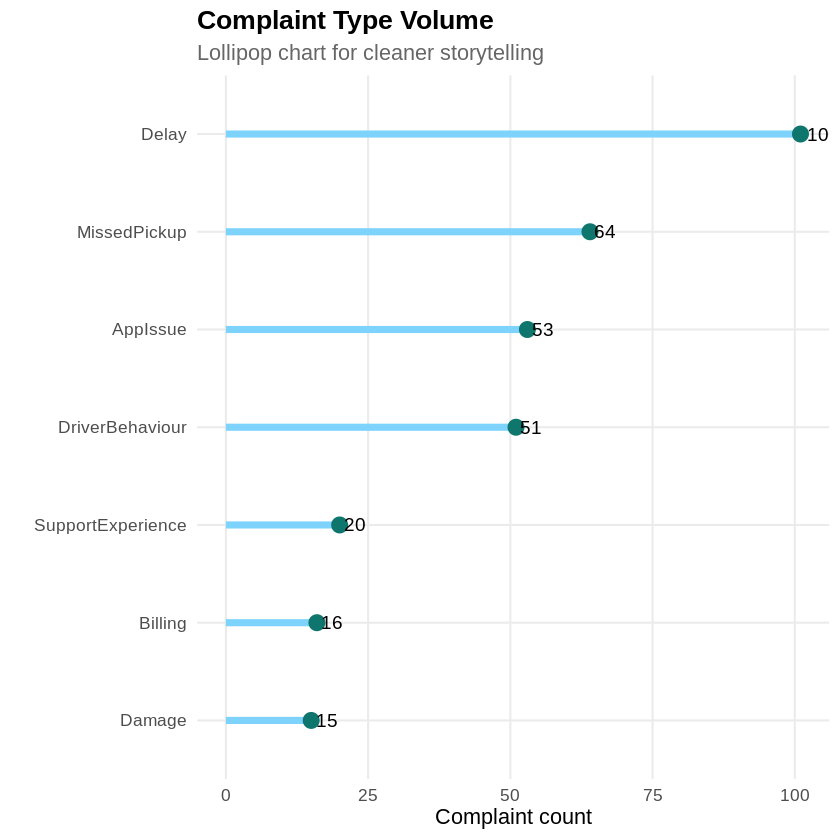

In [25]:
complaint_counts <- complaints %>%
  count(complaint_type, sort = TRUE) %>%
  arrange(n)

ggplot(complaint_counts, aes(x = n, y = fct_reorder(complaint_type, n))) +
  geom_segment(aes(x = 0, xend = n, yend = fct_reorder(complaint_type, n)),
               color = "#7dd3fc", linewidth = 2) +
  geom_point(size = 4, color = "#0f766e") +
  geom_text(aes(label = n), hjust = -0.2, size = 4) +
  labs(
    title = "Complaint Type Volume",
    subtitle = "Lollipop chart for cleaner storytelling",
    x = "Complaint count", y = NULL
  ) +
  theme_hi()

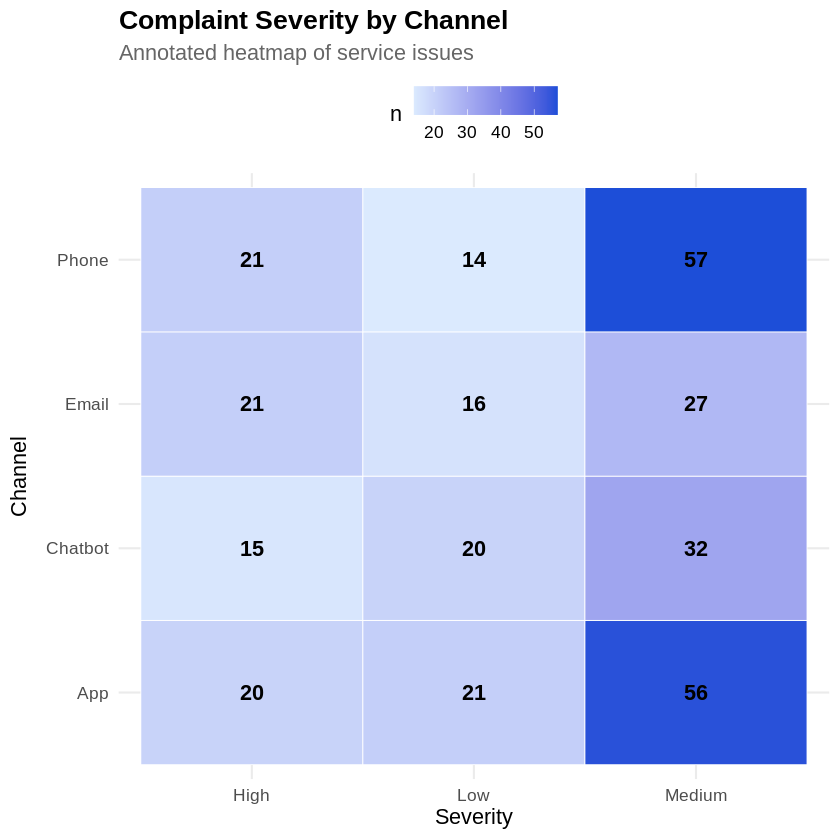

In [26]:
heat_df <- complaints %>%
  count(channel, severity)

ggplot(heat_df, aes(x = severity, y = channel, fill = n)) +
  geom_tile(color = "white") +
  geom_text(aes(label = n), fontface = "bold") +
  scale_fill_gradient(low = "#dbeafe", high = "#1d4ed8") +
  labs(
    title = "Complaint Severity by Channel",
    subtitle = "Annotated heatmap of service issues",
    x = "Severity", y = "Channel"
  ) +
  theme_hi()

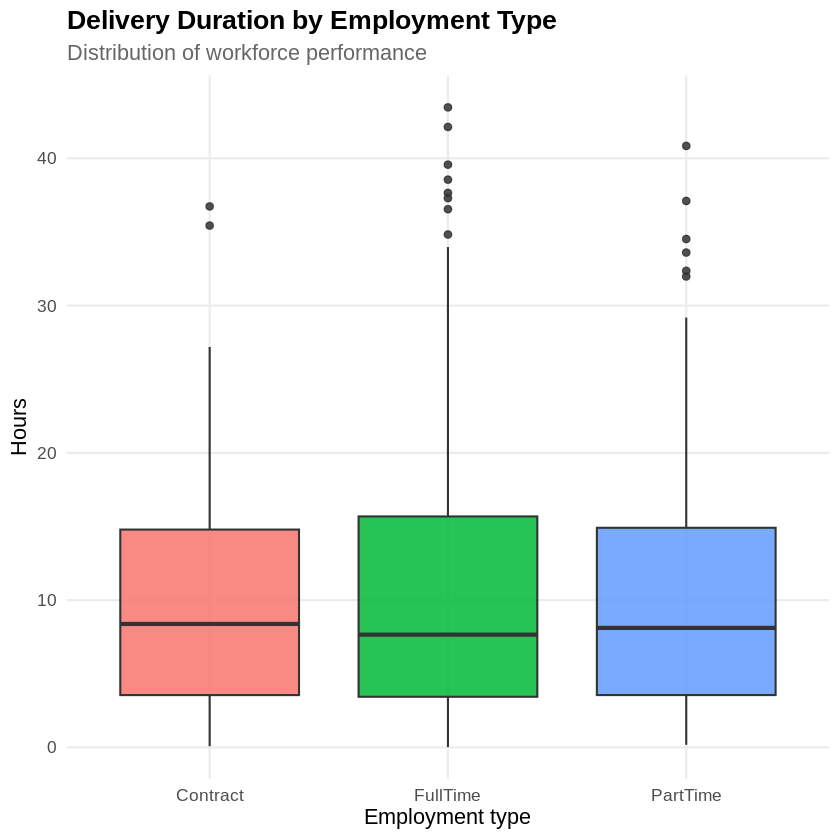

In [27]:
box_df <- deliveries %>%
  left_join(drivers, by = "driver_id") %>% # Corrected column name
  filter(!is.na(delivery_duration_hours))

ggplot(box_df, aes(x = employment_type, y = delivery_duration_hours, fill = employment_type)) + # Corrected column name
  geom_boxplot(alpha = 0.85) +
  labs(
    title = "Delivery Duration by Employment Type",
    subtitle = "Distribution of workforce performance",
    x = "Employment type", y = "Hours"
  ) +
  theme_hi() +
  theme(legend.position = "none")

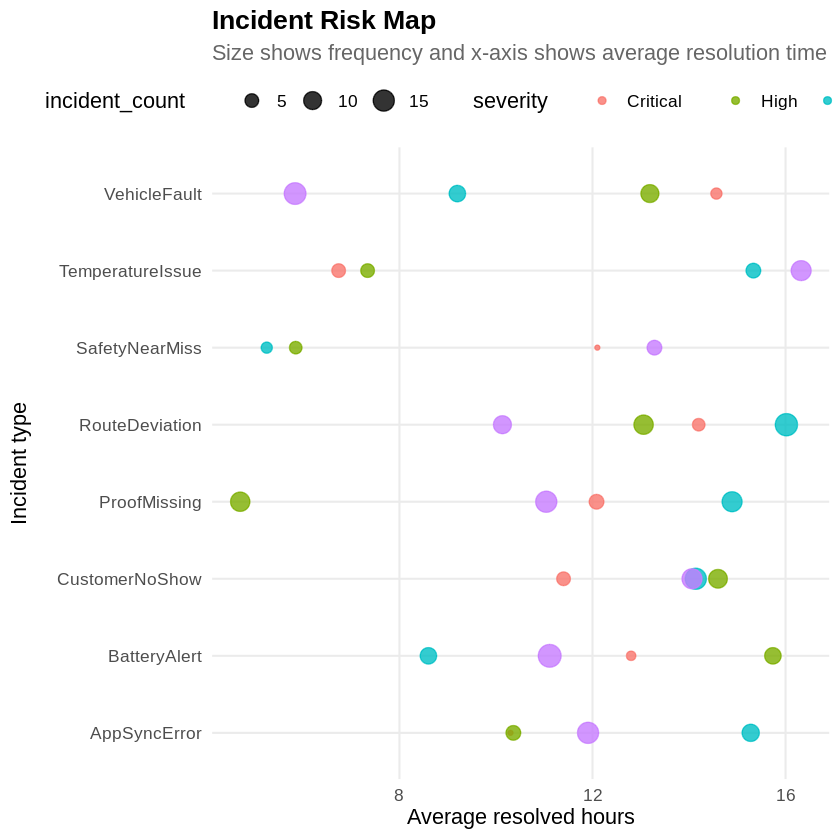

In [28]:
bubble_df <- incidents %>%
  count(incident_type, severity, name = "incident_count") %>%
  left_join(
    incidents %>%
      group_by(incident_type, severity) %>%
      summarise(avg_resolvedhours = mean(resolved_hours, na.rm = TRUE), .groups = "drop"),
    by = c("incident_type", "severity")
  )

ggplot(bubble_df, aes(x = avg_resolvedhours, y = incident_type, size = incident_count, color = severity)) +
  geom_point(alpha = 0.8) +
  labs(
    title = "Incident Risk Map",
    subtitle = "Size shows frequency and x-axis shows average resolution time",
    x = "Average resolved hours", y = "Incident type"
  ) +
  theme_hi()